#Libs


In [ ]:
!pip install gdown

In [ ]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
import seaborn as sns
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from math import sqrt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="darkgrid", palette="muted")


In [ ]:
#

url = 'https://drive.google.com/uc?id=1-jIhgKchXjhlB6oWZ_M-ut0wJnck0ZCr'
output = 'q_data.csv'
gdown.download(url, output, quiet=False)



Downloading...
From: https://drive.google.com/uc?id=1-jIhgKchXjhlB6oWZ_M-ut0wJnck0ZCr
To: /content/q_data.csv
100%|██████████| 161k/161k [00:00<00:00, 20.1MB/s]


'q_data.csv'

In [ ]:
quarterly_df = pd.read_csv('q_data.csv')
quarterly_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   municipio               656 non-null    object 
 1   quarter                 656 non-null    object 
 2   pib_mun                 656 non-null    float64
 3   total_pixeles_median    656 non-null    float64
 4   suma_rad_trend_sum      656 non-null    float64
 5   suma_rad_trend_mean     656 non-null    float64
 6   suma_rad_trend_std      656 non-null    float64
 7   suma_rad_trend_median   656 non-null    float64
 8   media_rad_trend_mean    656 non-null    float64
 9   std_rad_trend_mean      656 non-null    float64
 10  max_rad_trend_max       656 non-null    float64
 11  min_rad_trend_min       656 non-null    float64
 12  p25_rad_trend_mean      656 non-null    float64
 13  mediana_rad_trend_mean  656 non-null    float64
 14  p75_rad_trend_mean      656 non-null    fl

In [ ]:
def preprocess(dataframe, log = True,  encode = True, n_lags= 2, ):
  df = dataframe.copy()

  df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
  df['fecha'] = df['quarter'].dt.to_timestamp(how='end')
  df['year'] = df['fecha'].dt.year

  log_cols =  ['pib_mun', 'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean']

  if log:
    df[log_cols] = df[log_cols].replace(0, 1e-5)
    df[log_cols]= df[log_cols].apply(np.log)

  df = df.sort_values(['municipio', 'quarter'])

  col = 'suma_rad_trend_median'

  for lag in range(1, n_lags + 1):
    df[f'{col}_lag{lag}'] = df.groupby('municipio')[col].shift(lag)

  if encode:
    df = pd.get_dummies(
        df,
        columns= ['municipio'],
        drop_first=False,
        dtype=int
    )

    df = df.dropna()

  return df

In [ ]:
df_processed = preprocess(quarterly_df)

In [ ]:
df_processed.columns

Index(['quarter', 'pib_mun', 'total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'fecha', 'year', 'suma_rad_trend_median_lag1',
       'suma_rad_trend_median_lag2', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco'],
      dtype='object')

# Vanilla

In [ ]:
# Kfold falso

features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco']


X = df_processed[features]
y = df_processed['pib_mun']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)

y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# 2. Entrenar OLS en datos escalados
X_ols = sm.add_constant(X_scaled)
ols_model = sm.OLS(y_scaled, X_ols).fit()
y_hat_ols = ols_model.predict(X_ols)
residuals_ols = y_scaled - y_hat_ols

# 3. Entrenar RF en los residuales (SIN la constante)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
rf.fit(X_scaled, residuals_ols)

#pred

# ols
y_pred_ols_scaled = y_hat_ols

# rf on resids
y_pred_rf_scaled = rf.predict(X_scaled)

# pred hyb
y_pred_hybrid_scaled = y_pred_ols_scaled + y_pred_rf_scaled

# Desescalar predicción
y_pred_hybrid = scaler_y.inverse_transform(
    y_pred_hybrid_scaled.values.reshape(-1, 1)
).ravel()

# metricas

y_real = np.exp(y)
y_pred_real = np.exp(y_pred_hybrid)

fold_global_metrics = []

mse = mean_squared_error(y_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_real, y_pred_real)

# Convertir de log a escala original

mape = np.mean(np.abs((y_real - y_pred_real) / y_real)) * 100


fold_global_metrics.append({
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape
})



residuals_hybrid = y - y_pred_hybrid
print(fold_global_metrics)


[{'MSE': 1662738.4304764832, 'RMSE': np.float64(1289.4721518809483), 'MAE': 836.9876465269216, 'MAPE': np.float64(0.49335596527032055)}]


# Residuos

In [ ]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     8416.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        01:50:50   Log-Likelihood:                 969.77
No. Observations:                 624   AIC:                            -1884.
Df Residuals:                     596   BIC:                            -1759.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

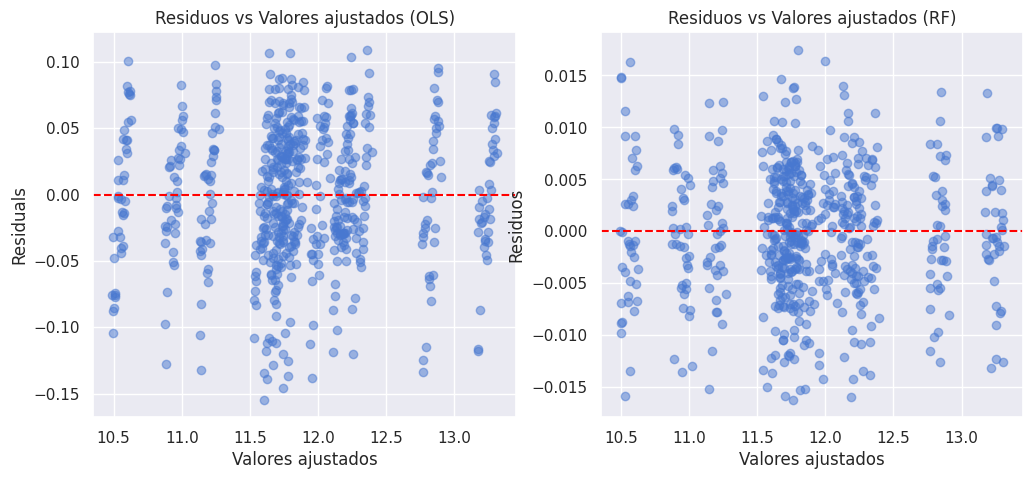

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_hybrid, residuals_ols, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores ajustados")
plt.ylabel("Residuals")
plt.title("Residuos vs Valores ajustados (OLS)")
plt.subplot(1,2,2)
plt.scatter(y_pred_hybrid, residuals_hybrid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores ajustados (RF)")
plt.show()

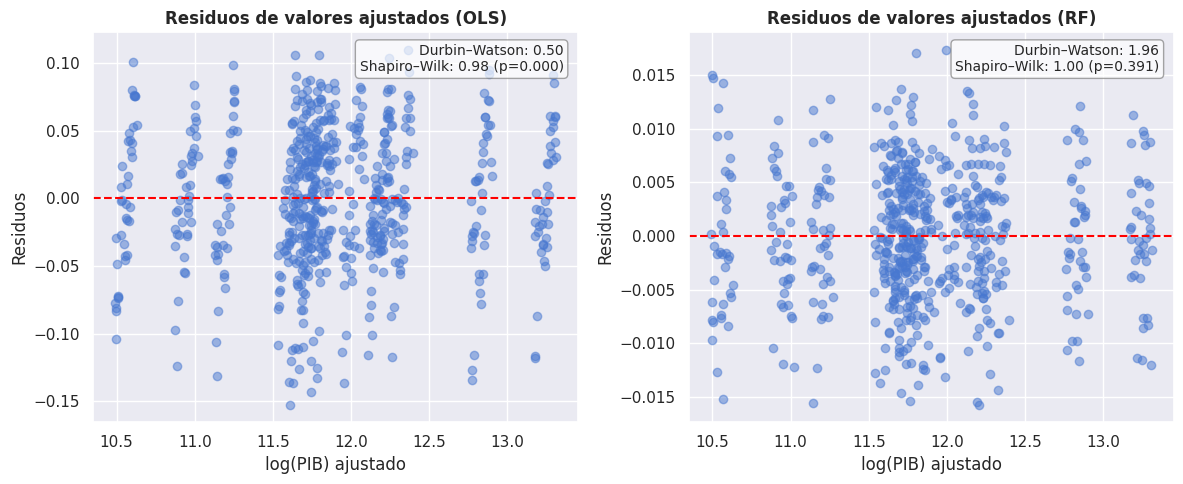

In [ ]:
# --- Calculate statistics ---
dw_ols = durbin_watson(residuals_ols)
sw_ols_stat, sw_ols_p = shapiro(residuals_ols)

dw_rf = durbin_watson(residuals_hybrid)
sw_rf_stat, sw_rf_p = shapiro(residuals_hybrid)

# --- Plot ---
plt.figure(figsize=(12,5))

# OLS
plt.subplot(1,2,1)
plt.scatter(y_pred_hybrid, residuals_ols, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados (OLS)",fontweight="bold")

#
plt.annotate(
    f"Durbin–Watson: {dw_ols:.2f}\nShapiro–Wilk: {sw_ols_stat:.2f} (p={sw_ols_p:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

# RF
plt.subplot(1,2,2)
plt.scatter(y_pred_hybrid, residuals_hybrid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados (RF)",fontweight="bold")

#
plt.annotate(
    f"Durbin–Watson: {dw_rf:.2f}\nShapiro–Wilk: {sw_rf_stat:.2f} (p={sw_rf_p:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.tight_layout()
plt.show()

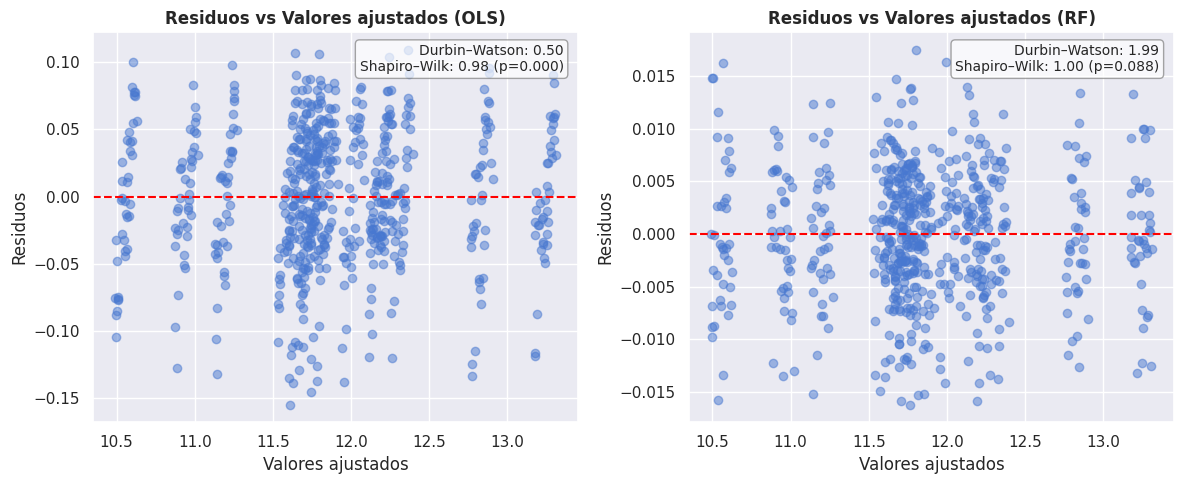

In [ ]:
# --- Calculate statistics ---
dw_ols = durbin_watson(residuals_ols)
sw_ols_stat, sw_ols_p = shapiro(residuals_ols)

dw_rf = durbin_watson(residuals_hybrid)
sw_rf_stat, sw_rf_p = shapiro(residuals_hybrid)

# --- Plot ---
plt.figure(figsize=(12,5))

# OLS
plt.subplot(1,2,1)
plt.scatter(y_pred_hybrid, residuals_ols, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados (OLS)",fontweight="bold")

#
plt.annotate(
    f"Durbin–Watson: {dw_ols:.2f}\nShapiro–Wilk: {sw_ols_stat:.2f} (p={sw_ols_p:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

# RF
plt.subplot(1,2,2)
plt.scatter(y_pred_hybrid, residuals_hybrid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados (RF)",fontweight="bold")

#
plt.annotate(
    f"Durbin–Watson: {dw_rf:.2f}\nShapiro–Wilk: {sw_rf_stat:.2f} (p={sw_rf_p:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.tight_layout()
plt.show()

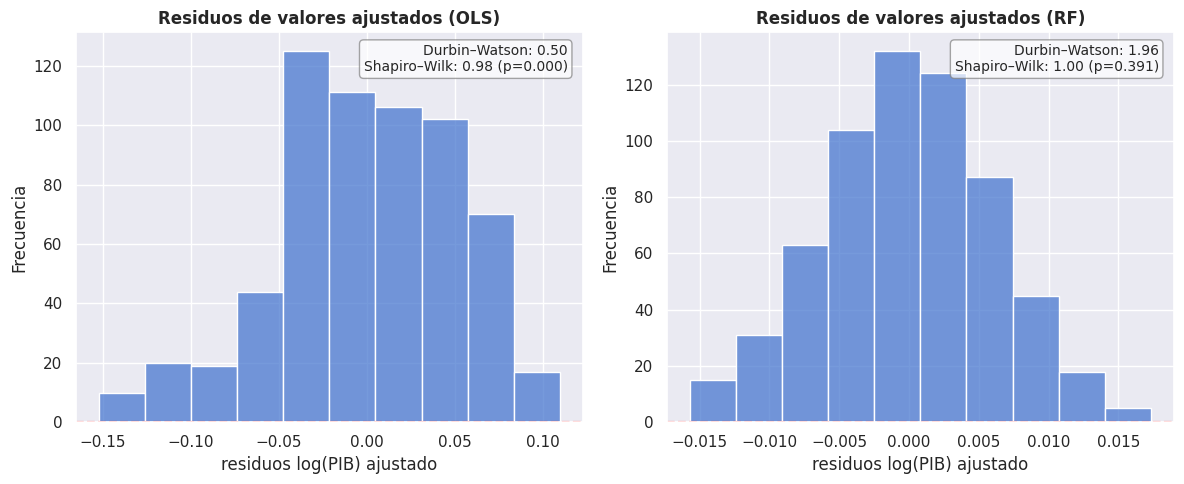

In [ ]:
# --- Calculate statistics ---
dw_ols = durbin_watson(residuals_ols)
sw_ols_stat, sw_ols_p = shapiro(residuals_ols)

dw_rf = durbin_watson(residuals_hybrid)
sw_rf_stat, sw_rf_p = shapiro(residuals_hybrid)

# --- Plot ---
plt.figure(figsize=(12,5))

bins = int(1 + np.log2(len(residuals_ols)))
# OLS
plt.subplot(1,2,1)
sns.histplot(residuals_ols, bins=bins)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("residuos log(PIB) ajustado")
plt.ylabel("Frecuencia")
plt.title("Residuos de valores ajustados (OLS)",fontweight="bold")

#
plt.annotate(
    f"Durbin–Watson: {dw_ols:.2f}\nShapiro–Wilk: {sw_ols_stat:.2f} (p={sw_ols_p:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

# RF
plt.subplot(1,2,2)
sns.histplot(residuals_hybrid, bins=bins)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("residuos log(PIB) ajustado")
plt.ylabel("Frecuencia")
plt.title("Residuos de valores ajustados (RF)",fontweight="bold")

#
plt.annotate(
    f"Durbin–Watson: {dw_rf:.2f}\nShapiro–Wilk: {sw_rf_stat:.2f} (p={sw_rf_p:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.tight_layout()
plt.show()

# KFold

In [ ]:
df_processed['y_pred_hybrid'] = y_pred_hybrid


municipios = [
    'azcapotzalco', 'alvaro obregon','benito juarez', 'coyoacan', 'cuajimalpa de morelos',
    'cuauhtemoc', 'gustavo a. madero', 'iztacalco', 'iztapalapa',
    'la magdalena contreras', 'miguel hidalgo', 'milpa alta', 'tlahuac',
    'tlalpan', 'venustiano carranza', 'xochimilco'
]


metricas = []

for m in municipios:
    col = f'municipio_{m}'
    df_mun = df_processed[df_processed[col] == 1].sort_values('fecha')

    df_mun = df_mun.dropna(subset=['pib_mun', 'y_pred_hybrid'])

    if len(df_mun) < 2:
        continue


    y_test = df_mun['pib_mun'].values
    y_pred = df_mun['y_pred_hybrid'].values

    y_test_real = np.exp(y_test)
    y_pred_real = np.exp(y_pred)


    mse_m = mean_squared_error(y_test_real, y_pred_real)
    rmse_m = np.sqrt(mse_m)
    mae_m = mean_absolute_error(y_test_real, y_pred_real)


    mape_m = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    metricas.append({
            'Municipio': m.capitalize(),
            'MSE': mse_m,
            'RMSE': rmse_m,
            'MAE': mae_m,
            'MAPE': mape_m
        })

df_metricas = pd.DataFrame(metricas)
print("\n Métricas por municipio:")
print(df_metricas)



 Métricas por municipio:
                 Municipio           MSE         RMSE          MAE      MAPE
0             Azcapotzalco  6.096661e+05   780.811211   665.240926  0.500619
1           Alvaro obregon  1.691502e+06  1300.577698  1078.822990  0.480629
2            Benito juarez  4.887830e+05   699.130152   577.095697  0.485160
3                 Coyoacan  1.148625e+06  1071.739110   836.716455  0.429092
4    Cuajimalpa de morelos  1.056122e+05   324.980272   271.353000  0.478017
5               Cuauhtemoc  1.035554e+06  1017.621650   829.710813  0.506290
6        Gustavo a. madero  5.128793e+06  2264.683763  1878.277875  0.503312
7                Iztacalco  5.631881e+05   750.458625   582.277915  0.468425
8               Iztapalapa  1.163301e+07  3410.720125  2655.556582  0.468442
9   La magdalena contreras  2.066707e+05   454.610468   368.431621  0.505305
10          Miguel hidalgo  3.840548e+05   619.721519   510.973363  0.439952
11              Milpa alta  8.048282e+04   283.694

In [ ]:
df_metricas.to_csv("output.csv",index=False)

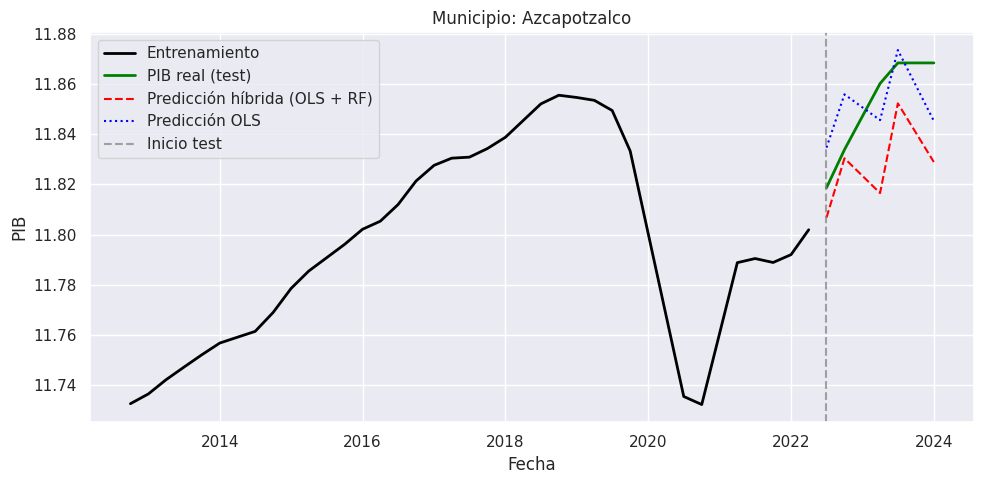

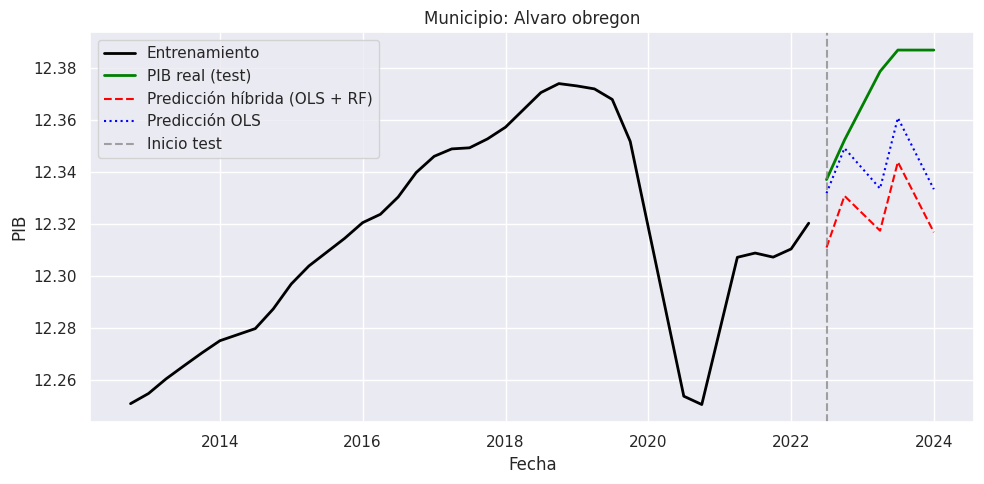

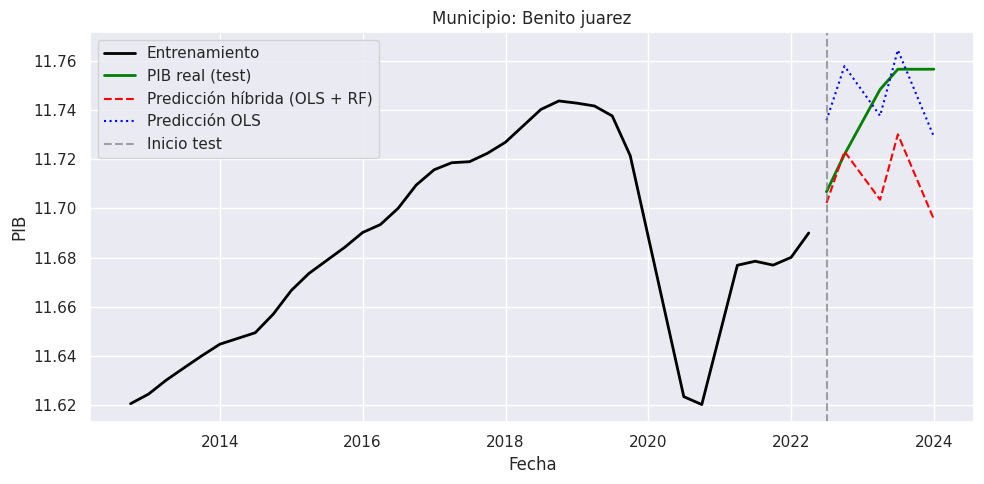

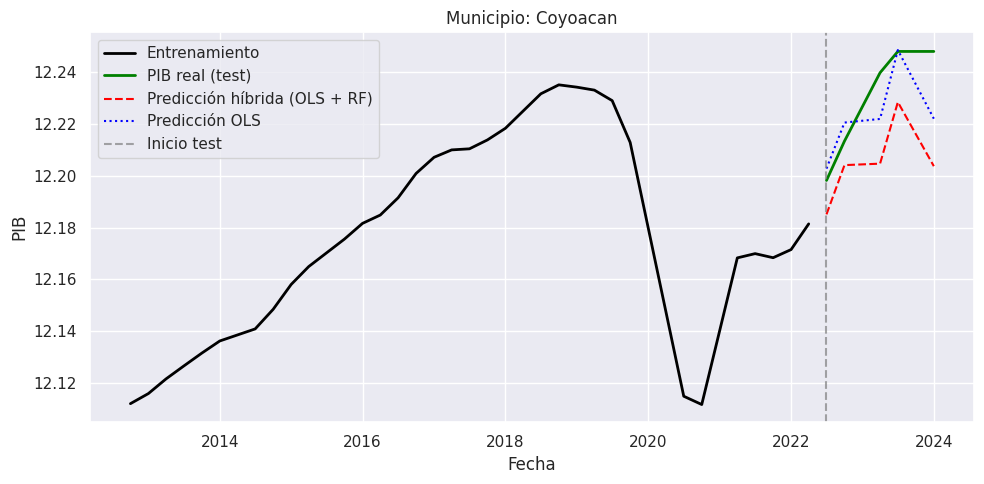

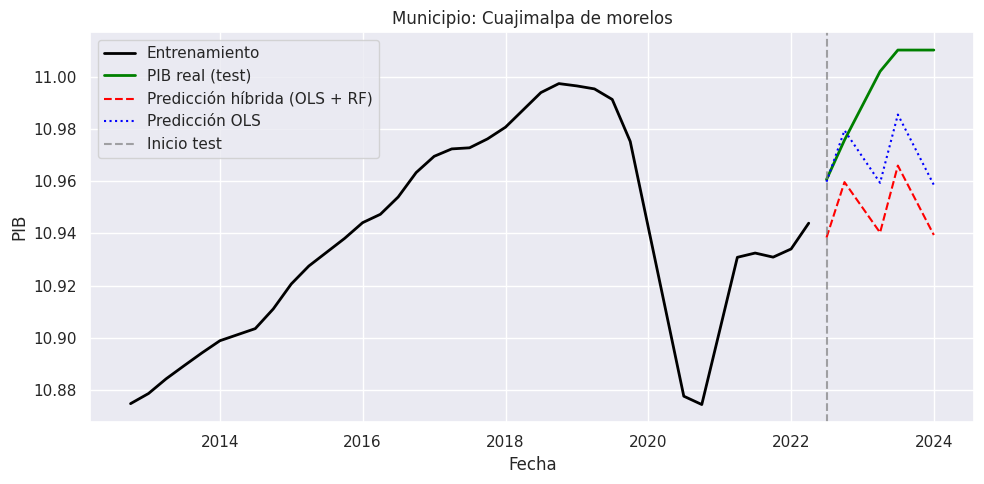

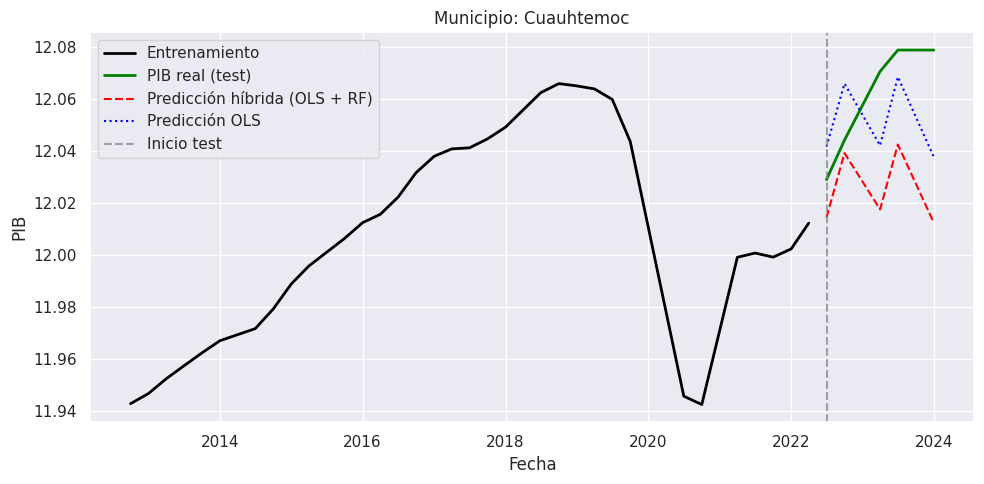

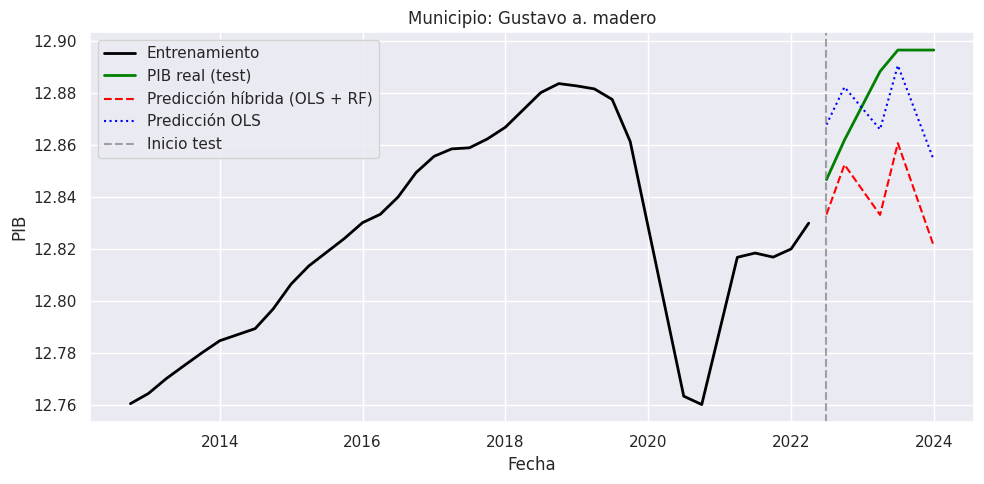

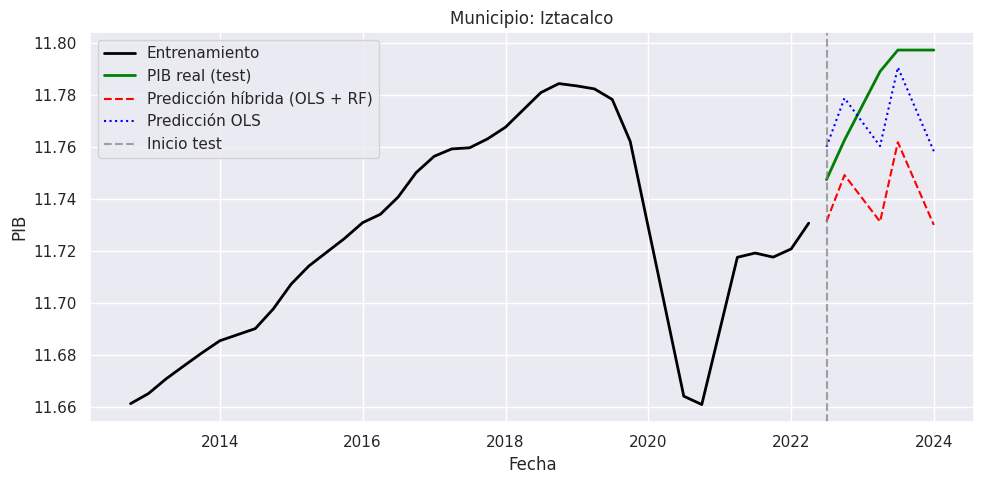

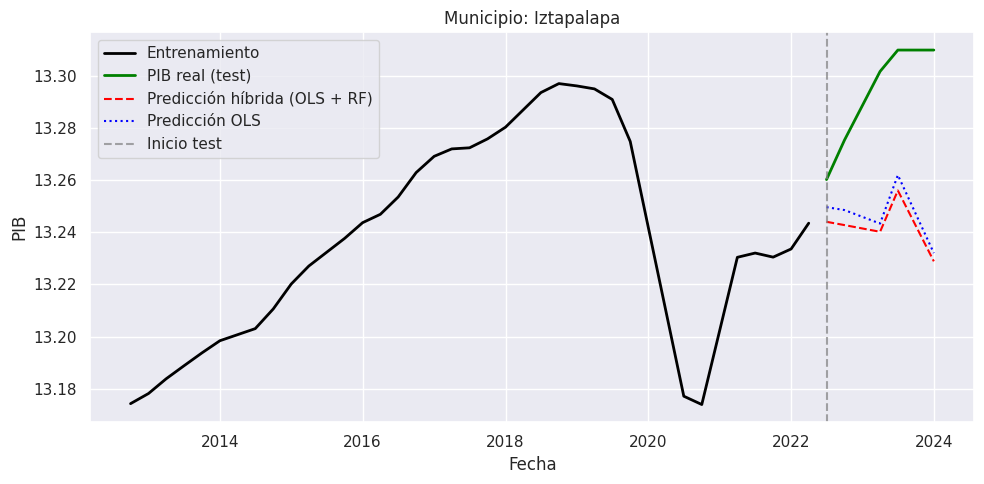

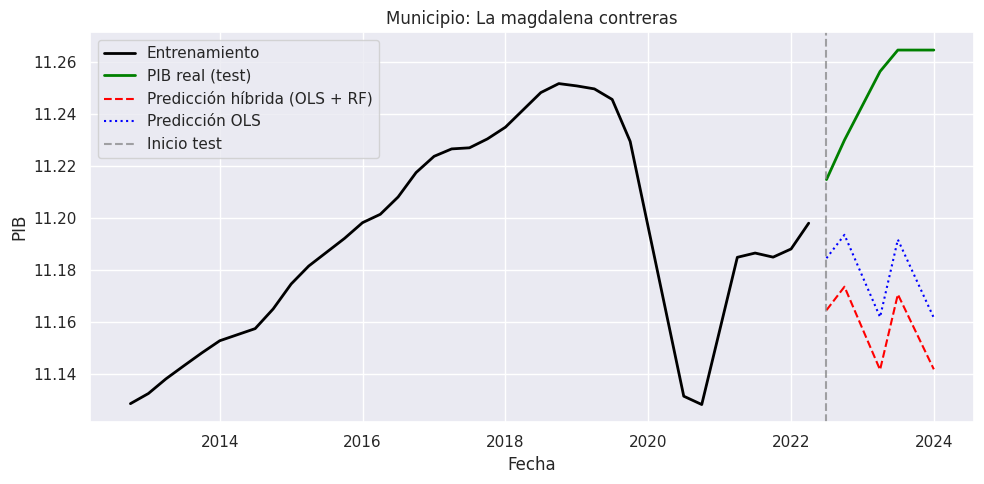

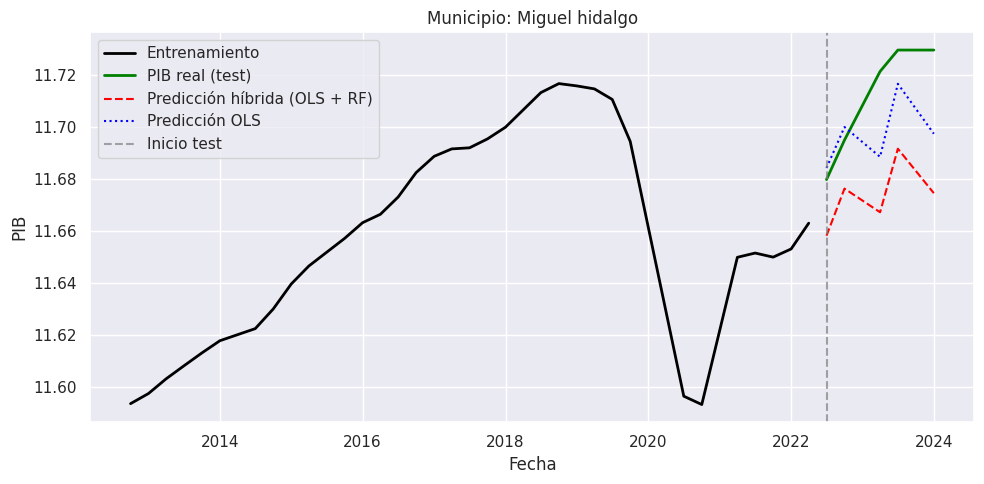

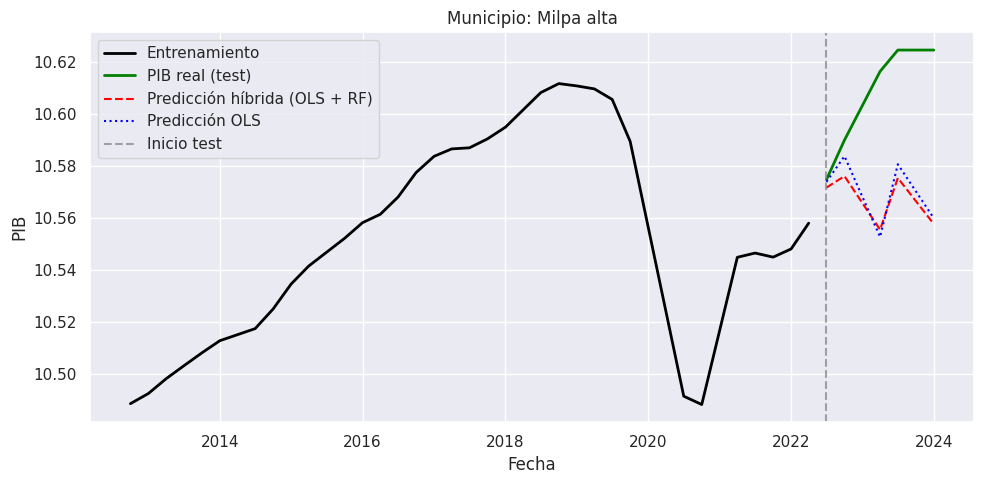

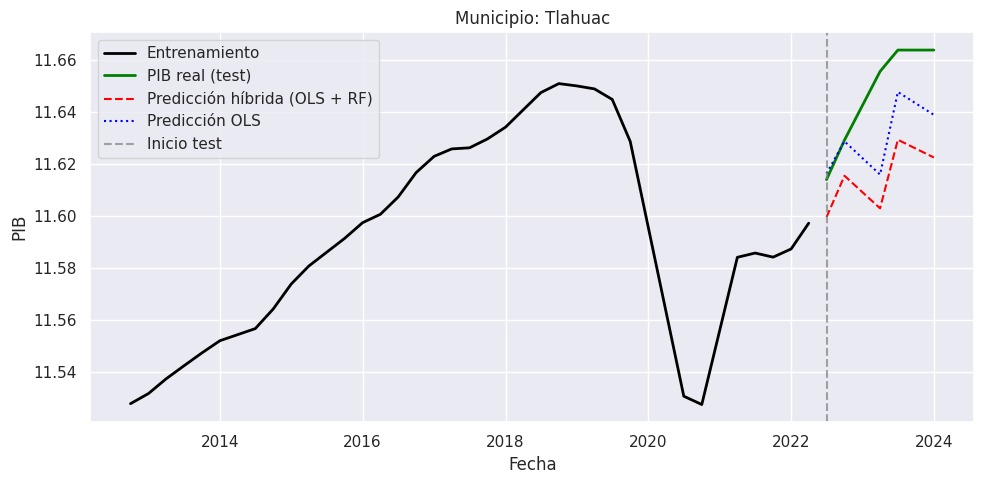

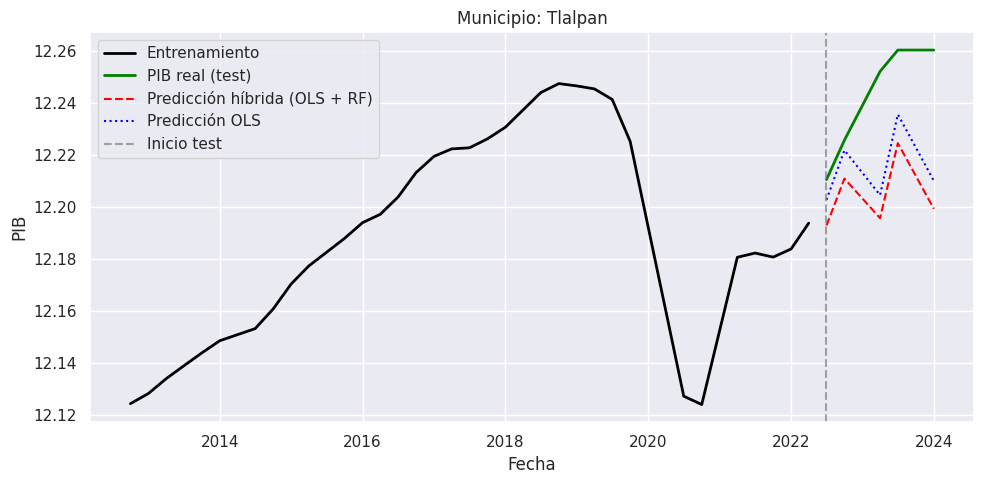

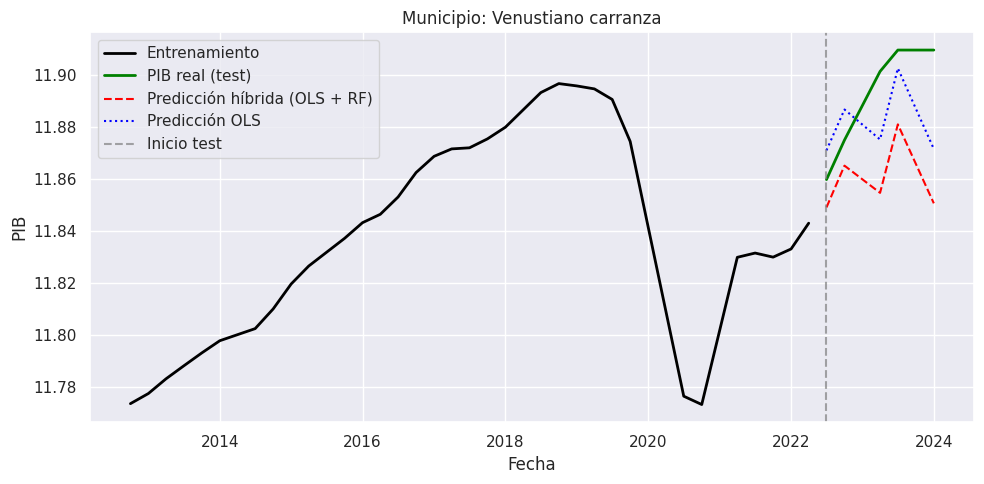

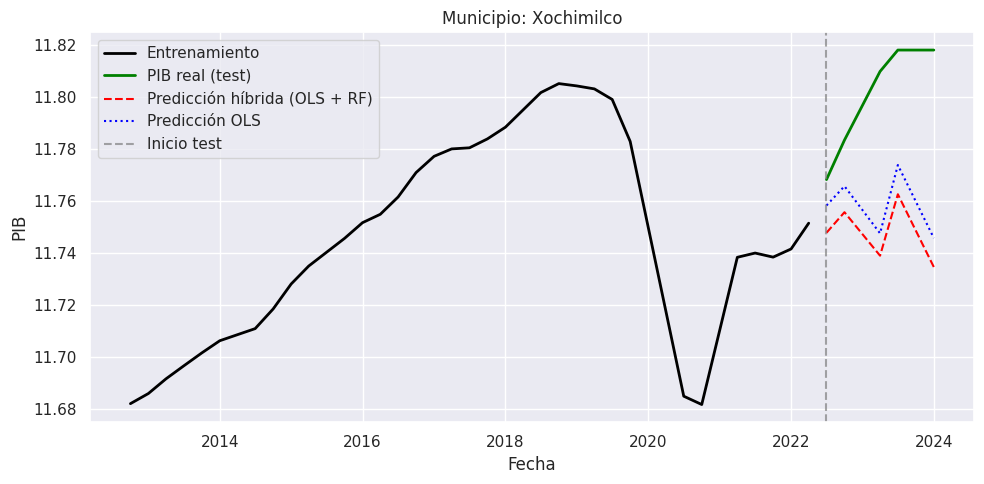

In [ ]:
# Initialize empty dataframes with specified dtypes
X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

n_preds = 5

# tomar los ultimos n trimestres de cada municipio
for mun in municipios:
    col = f'municipio_{mun}'
    df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()

    if len(df_mun) <= 4:
        continue


    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['pib_mun'].iloc[:-n_preds].astype(float)
    y_mun_test = df_mun['pib_mun'].iloc[-n_preds:].astype(float)


    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])



X_train_ols = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_ols).fit()
y_hat_train_ols = ols_model.predict(X_train_ols)
residuals_train = y_train - y_hat_train_ols

rf = RandomForestRegressor(
            n_estimators=50,
            max_leaf_nodes=None,
            max_depth=20,
            min_samples_leaf= 1,
            random_state=42
        )
rf.fit(X_train, residuals_train)

X_test_ols = sm.add_constant(X_test, has_constant='add')
y_hat_test_ols = ols_model.predict(X_test_ols)
y_hat_test_rf = rf.predict(X_test)
y_pred_hybrid_test = y_hat_test_ols + y_hat_test_rf

df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred_hybrid'] = y_pred_hybrid_test
df_test['y_pred_ols'] = y_hat_test_ols

for m in municipios:
    col = f'municipio_{m}'


    df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
    # Datos test
    df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    plt.figure(figsize=(10, 5))


    if not df_mun_train.empty:
        plt.plot(df_mun_train['fecha'], df_mun_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)

    # PIB real en test
    if not df_mun_test.empty:
        plt.plot(df_mun_test['fecha'], df_mun_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2)
        # Predicción híbrida
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred_hybrid'],
                 label='Predicción híbrida (OLS + RF)', color='red', linestyle='--')
        # Predicción OLS
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred_ols'],
                 label='Predicción OLS', color='blue', linestyle=':')

        # Línea vertical que separa train/test
        plt.axvline(x=df_mun_test['fecha'].iloc[0], color='gray', linestyle='--', alpha=0.7, label='Inicio test')

    plt.title(f'Municipio: {m.capitalize()}')
    plt.xlabel('Fecha')
    plt.ylabel('PIB')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# Timesplit CV

In [ ]:
features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco']

municipios = [
    'alvaro obregon', 'azcapotzalco', 'benito juarez', 'coyoacan',
    'cuajimalpa de morelos', 'cuauhtemoc', 'gustavo a. madero', 'iztacalco',
    'iztapalapa', 'la magdalena contreras', 'miguel hidalgo', 'milpa alta',
    'tlahuac', 'tlalpan', 'venustiano carranza', 'xochimilco'
]

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []
fold_metricas_mun = []

# Asegurarse de que el df esté ordenado por fecha
df_processed_sorted = df_processed.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['pib_mun']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n🔄 Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Escalar X e y
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Convertir X escalados de vuelta a DataFrame para mantener nombres de columnas
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Paso 1: Entrenar OLS en datos escalados
    X_train_ols = sm.add_constant(X_train_scaled_df)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_train_ols = ols_model.predict(X_train_ols)
    residuals_train = y_train_scaled - y_hat_train_ols

    # Paso 2: Entrenar RF en los residuales
    rf = RandomForestRegressor(
            n_estimators=50,
            max_leaf_nodes=None,
            max_depth=20,
            min_samples_leaf= 1,
            random_state=42
        )
    rf.fit(X_train_scaled_df, residuals_train)

    # Paso 3: Predicción híbrida en test (escalado)
    X_test_ols = sm.add_constant(X_test_scaled_df, has_constant='add')
    y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
    y_hat_test_rf_scaled = rf.predict(X_test_scaled_df)
    y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

    # Desescalar las predicciones
    y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.values.reshape(-1, 1)).ravel()

    # Convertir todo a numpy arrays del mismo tamaño
    y_test_values = y_test.values
    y_pred = np.array(y_pred_hybrid)

    y_test_real = np.exp(y_test_values)
    y_pred_real = np.exp(y_pred)

    # Métricas globales del fold
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)


    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


    fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    # Métricas por municipio dentro del fold
    for m in municipios:
        col = f'municipio_{m}'
        # Crear máscara para el municipio en el test set
        mask = df_processed_sorted[col].iloc[test_idx].values == 1

        if mask.sum() == 0 or mask.sum() < 2:
            continue

        # Filtrar los valores del municipio
        y_test_mun = y_test_values[mask]
        y_pred_mun = y_pred[mask]

        y_test_real = np.exp(y_test_mun)
        y_pred_real = np.exp(y_pred_mun)

        mse_m = mean_squared_error(y_test_real, y_pred_real)
        rmse_m = np.sqrt(mse_m)
        mae_m = mean_absolute_error(y_test_real, y_pred_real)


        mape_m = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

        fold_metricas_mun.append({
            'Municipio': m.capitalize(),
            'MSE': mse_m,
            'RMSE': rmse_m,
            'MAE': mae_m,
            'MAPE': mape_m
        })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics)
print("\n" + "="*60)
print("Metricas globales:")
print("="*60)
print(df_global_metrics.mean())
print("\n📋 Metrics per fold:")
print(df_global_metrics)

# Métricas promedio por municipio entre folds
df_metricas_per_mun = pd.DataFrame(fold_metricas_mun)
df_metricas_per_mun_avg = df_metricas_per_mun.groupby('Municipio').mean().reset_index()
print("\n" + "="*60)
print("Metricas por municipop:")
print("="*60)
print(df_metricas_per_mun_avg.to_string(index=False))


🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...

Metricas globales:
MSE     1.439215e+08
RMSE    9.653293e+03
MAE     6.277280e+03
MAPE    3.571118e+00
dtype: float64

📋 Metrics per fold:
            MSE          RMSE           MAE       MAPE
0  7.560097e+07   8694.881676   3255.452595   1.540703
1  6.601711e+06   2569.379435   1794.748828   1.000038
2  2.011979e+07   4485.508734   2446.137722   1.354765
3  5.250888e+08  22914.816430  17928.397807  10.661503
4  9.219610e+07   9601.880104   5961.661988   3.298581

Metricas por municipop:
             Municipio          MSE         RMSE          MAE     MAPE
        Alvaro obregon 1.260385e+08  8238.462090  7495.949069 3.375479
          Azcapotzalco 4.534800e+07  4832.240748  4399.709188 3.334133
         Benito juarez 3.807011e+07  4416.626661  3960.994595 3.350360
              Coyoacan 9.119201e+07  6916.677816  6218.976697 3.230468
 Cuajimalpa de morel

In [ ]:
df_metricas_per_mun_avg.to_csv('output.csv',index=False)

# Forecast


In [ ]:
features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco']

X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

municipios = [
    'alvaro obregon', 'azcapotzalco', 'benito juarez', 'coyoacan', 'cuajimalpa de morelos',
    'cuauhtemoc', 'gustavo a. madero', 'iztacalco', 'iztapalapa',
    'la magdalena contreras', 'miguel hidalgo', 'milpa alta', 'tlahuac',
    'tlalpan', 'venustiano carranza', 'xochimilco'
]

n_preds = 4

# Tomar los últimos n trimestres de cada municipio
for mun in municipios:
    col = f'municipio_{mun}'
    df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()

    if len(df_mun) <= n_preds:
        continue

    # Dividir en train/test
    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['pib_mun'].iloc[:-n_preds].astype(float)
    y_mun_test = df_mun['pib_mun'].iloc[-n_preds:].astype(float)

    # Concatenar
    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])

# Escalar datos
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

#Paso 1: Entrenar OLS en datos escalados
X_train_ols = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
y_hat_train_ols = ols_model.predict(X_train_ols)
residuals_train = y_train_scaled - y_hat_train_ols

# Paso 2: Entrenar RF en los residuales
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train_scaled, residuals_train)

# Paso 3: Predicción híbrida en test (escalado)
X_test_ols = sm.add_constant(X_test_scaled, has_constant='add')
y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
y_hat_test_rf_scaled = rf.predict(X_test_scaled)
y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

# Desescalar las predicciones
y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.reshape(-1, 1)).ravel()

# Convertir todo a numpy arrays del mismo tamaño
y_test = y_test.values
y_pred = np.array(y_pred_hybrid)

y_real = np.exp(y_test)
y_pred_real = np.exp(y_pred)

# Métricas
fold_global_metrics = []

mse = mean_squared_error(y_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_real, y_pred_real)

# Convertir de log a escala original
y_real = np.exp(y_test)
y_pred_real = np.exp(y_pred)
mape = np.mean(np.abs((y_real - y_pred_real) / y_real)) * 100


fold_global_metrics.append({
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape
})

print(fold_global_metrics)

# Preparar datos para visualización
df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred

metricas = []

# Graficar por municipio
for m in municipios:
    col = f'municipio_{m}'

    df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
    df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    y_test = df_mun_test['y_real']
    y_pred = df_mun_test['y_pred']

    y_test_real = np.exp(y_test)
    y_pred_real = np.exp(y_pred)

    mse_m = mean_squared_error(y_test_real, y_pred_real)
    rmse_m = np.sqrt(mse_m)
    mae_m = mean_absolute_error(y_test_real, y_pred_real)


    mape_m = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    metricas.append({
            'Municipio': m.capitalize(),
            'MSE': mse_m,
            'RMSE': rmse_m,
            'MAE': mae_m,
            'MAPE': mape_m
        })




df_metricas = pd.DataFrame(metricas)
print("\n Métricas por municipio:")
print(df_metricas)

[{'MSE': 96901615.07726157, 'RMSE': np.float64(9843.861796940344), 'MAE': 6290.669438704004, 'MAPE': np.float64(3.337939905358879)}]

 Métricas por municipio:
                 Municipio           MSE          RMSE           MAE      MAPE
0           Alvaro obregon  8.664404e+07   9308.277843   8027.577815  3.363184
1             Azcapotzalco  1.465002e+07   3827.534827   3276.517069  2.307918
2            Benito juarez  1.911058e+07   4371.564864   3892.963195  3.068725
3                 Coyoacan  2.769341e+07   5262.453308   4416.805162  2.126148
4    Cuajimalpa de morelos  4.645800e+06   2155.411748   1872.285790  3.107182
5               Cuauhtemoc  4.627929e+07   6802.888627   5963.243045  3.401482
6        Gustavo a. madero  2.485372e+08  15765.063022  13212.858832  3.323299
7                Iztacalco  2.371653e+07   4869.962191   4112.603416  3.106107
8               Iztapalapa  9.189514e+08  30314.210870  28148.203668  4.695103
9   La magdalena contreras  2.679926e+07   5176.800

In [ ]:
df_metricas.to_csv('output.csv',index=False)